In [1]:
#import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

In [2]:
#import database/data
conn=sqlite3.connect('customer_churn.db')
sql_query="""
SELECT name
FROM sqlite_master
WHERE type='table'


"""
tables=pd.read_sql(sql_query,conn)
#create dataframe for each table
for table_name in tables['name']:
    df=pd.read_sql(f"SELECT * FROM {table_name}",conn)
    globals()[f"df_{table_name}"]=df
    print(f"Created dataframe: df_{table_name}")

conn.close()
    

Created dataframe: df_db_customer
Created dataframe: df_db_subscription
Created dataframe: df_db_support


In [3]:
#print table names and column names
conn=sqlite3.connect('customer_churn.db')

for table_name in tables['name']:
    print(f"\nTable Name:{table_name}")
    #get column info
    columns_query=f"PRAGMA table_info({table_name});"
    columns=pd.read_sql(columns_query,conn)
    print("Columns:")
    print(columns['name'].tolist())
conn.close()


Table Name:db_customer
Columns:
['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests', 'pincode']

Table Name:db_subscription
Columns:
['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score']

Table Name:db_support
Columns:
['customerid', 'complaint_date', 'escalations', 'csat_score', 'col_1', 'comment']


In [4]:
#2]data cleaning
df_db_customer.head()


,customerid,name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,None,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,None,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None


In [5]:
df_db_customer.tail()

,customerid,name,country,state,gender,dob,interests,pincode
16,0020-JDNXP,rikim,India,Meghalaya,Female,1994-08-19 00:00:00,None,None
17,0021-IKXGC,vishakha,India,Rajasthan,Female,2000-09-02 00:00:00,None,None
18,0022-TCJCI,raghvendra,India,Telangana,Male,1983-12-30 00:00:00,None,None
19,0023-HGHWL,rishabh,India,Uttar Pradesh,Men,1991-05-14 00:00:00,None,None
20,0023-UYUPN,sudevi,India,Maharashtra,Women,1977-10-06 00:00:00,None,None


In [6]:
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  21 non-null     object
 1   name        21 non-null     object
 2   country     18 non-null     object
 3   state       21 non-null     object
 4   gender      21 non-null     object
 5   dob         21 non-null     object
 6   interests   4 non-null      object
 7   pincode     0 non-null      object
dtypes: object(8)
memory usage: 1.4+ KB


In [7]:
#rename col -name to customer name
#drop columns-interest and pincode
#change dob data type
#data standardisation -gender
#fix missing values in country


In [8]:
#1]rename col -name to customer name
df_db_customer.rename(columns={'name':'customer_name'},inplace=True)
df_db_customer

,customerid,customer_name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,None,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,None,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None
5,0013-MHZWF,durga,None,Delhi,Women,1988-12-10 00:00:00,None,None
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21 00:00:00,None,None
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14 00:00:00,None,None
8,0015-UOCOJ,maya,None,Kathmandu,Women,1985-07-07 00:00:00,None,None
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29 00:00:00,None,None


In [9]:
#2]drop columns-interest and pincode
# df_db_customer.drop(df_db_customer.columns[-2:],axis=1,inplace=True)
# df_db_customer.drop(df_db_customer.columns[6:],axis=1,inplace=True)
df_db_customer.drop(columns=['interests','pincode'],inplace=True)
df_db_customer

,customerid,customer_name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00
5,0013-MHZWF,durga,None,Delhi,Women,1988-12-10 00:00:00
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21 00:00:00
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14 00:00:00
8,0015-UOCOJ,maya,None,Kathmandu,Women,1985-07-07 00:00:00
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29 00:00:00


In [10]:
#3]change dob data type
df_db_customer['dob']=pd.to_datetime(df_db_customer['dob'])

In [11]:
#4]data standardisation -gender
# df_db_customer['gender'].unique()
df_db_customer['gender']=df_db_customer['gender'].replace({'Men':'Male','Woman':'Female'})
df_db_customer

,customerid,customer_name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05
5,0013-MHZWF,durga,None,Delhi,Women,1988-12-10
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14
8,0015-UOCOJ,maya,None,Kathmandu,Women,1985-07-07
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29


In [12]:
#5]fix missing values in country
df_db_customer[df_db_customer['country'].isna()]


,customerid,customer_name,country,state,gender,dob
5,0013-MHZWF,durga,None,Delhi,Women,1988-12-10
8,0015-UOCOJ,maya,None,Kathmandu,Women,1985-07-07
12,0018-NYROU,chitra,None,Telangana,Female,2004-12-01


In [13]:
# df_db_customer[['country','state']]
#country and state -unique value pair
state_country_mapping=df_db_customer.dropna(subset=['country']).set_index('state')['country'].to_dict()
df_db_customer['country']=df_db_customer['country'].fillna(df_db_customer['state'].map(state_country_mapping))

In [14]:
# df_db_customer['country']=df_db_customer['country'].fillna('India')
# df_db_customer

In [15]:
df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob


In [16]:
df_db_customer[['country','state']]

,country,state
0,India,Maharashtra
1,India,Karnataka
2,India,Delhi
3,India,Nagaland
4,India,Delhi
5,India,Delhi
6,India,Meghalaya
7,India,Rajasthan
8,Nepal,Kathmandu
9,Nepal,Kathmandu


In [17]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,None,None,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,None,None,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,None,None,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [18]:
df_db_subscription.tail()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
16,0020-JDNXP,2022-01-19,Organic,2024-01-19,Premium,Annual,None,None,20.99,550,62
17,0021-IKXGC,2021-07-07,Paid,2025-07-07,Standard,Annual,None,None,13.99,840,27
18,0022-TCJCI,2023-09-14,Refferal,2024-09-14,Basic,Monthly,2024-09-14,Forgot to cancel trial,16.99,42,99
19,0023-HGHWL,2020-06-23,Organic,2025-06-23,Premium,Annual,None,None,22.99,1955,7
20,0023-UYUPN,2022-12-31,Paid,2025-12-31,Standard,Monthly,None,None,13.99,790,47


In [19]:
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               21 non-null     object 
 1   subscription_start_date  21 non-null     object 
 2   subscription_type        21 non-null     object 
 3   renewal_date             21 non-null     object 
 4   plan_type                21 non-null     object 
 5   contract_type            21 non-null     object 
 6   cancellation_date        6 non-null      object 
 7   cancellation_reason      6 non-null      object 
 8   monthly_charges          21 non-null     float64
 9   cltv                     21 non-null     int64  
 10  churn_score              21 non-null     int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 1.9+ KB


In [20]:
date_col=['subscription_start_date','renewal_date','cancellation_date']
df_db_subscription[date_col]=df_db_subscription[date_col].apply(pd.to_datetime)
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               21 non-null     object        
 1   subscription_start_date  21 non-null     datetime64[ns]
 2   subscription_type        21 non-null     object        
 3   renewal_date             21 non-null     datetime64[ns]
 4   plan_type                21 non-null     object        
 5   contract_type            21 non-null     object        
 6   cancellation_date        6 non-null      datetime64[ns]
 7   cancellation_reason      6 non-null      object        
 8   monthly_charges          21 non-null     float64       
 9   cltv                     21 non-null     int64         
 10  churn_score              21 non-null     int64         
dtypes: datetime64[ns](3), float64(1), int64(2), object(5)
memory usage: 1.9+ KB


In [21]:
df_db_support.head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,None
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,None


In [22]:
df_db_support.tail()

,customerid,complaint_date,escalations,csat_score,col_1,comment
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,None
5,0017-IUDMW,2024-04-10 00:00:00,Y,25,None,None
6,0019-EFAEP,2024-09-27 00:00:00,Y,30,None,None
7,0022-TCJCI,2024-09-13 00:00:00,Y,10,None,None
8,0022-TCJCI,2024-09-14 00:00:00,N,90,None,received refund


In [23]:
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      object
 1   complaint_date  9 non-null      object
 2   escalations     9 non-null      object
 3   csat_score      9 non-null      int64 
 4   col_1           0 non-null      object
 5   comment         4 non-null      object
dtypes: int64(1), object(5)
memory usage: 564.0+ bytes


In [24]:
df_db_support.drop(columns=['col_1','comment'],inplace=True)

In [25]:
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      object
 1   complaint_date  9 non-null      object
 2   escalations     9 non-null      object
 3   csat_score      9 non-null      int64 
dtypes: int64(1), object(3)
memory usage: 420.0+ bytes


In [90]:
df_db_support['complaint_date']=pd.to_datetime(df_db_support['complaint_date'])
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7 entries, 2 to 3
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   customerid       7 non-null      object        
 1   complaint_date   7 non-null      datetime64[ns]
 2   escalations      7 non-null      object        
 3   csat_score       7 non-null      int64         
 4   complaint_count  7 non-null      int64         
dtypes: datetime64[ns](1), int64(2), object(2)
memory usage: 336.0+ bytes


In [91]:
df['gender'] = df['gender'].replace('Women', 'Female')
df['gender'].tail()

16    Female
17    Female
18      Male
19      Male
20    Female
Name: gender, dtype: object

In [27]:
#cleaned all the three tables

In [28]:
#3.Feature Engineering and Data Analysis

In [29]:
#Create a new col using existing col-churn flag
df_db_subscription['churn_flag']=np.where(df_db_subscription['cancellation_date'].notna(),1,0)

In [30]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,34,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,8,0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1


In [31]:
#first fix support table then merge
df=(df_db_subscription
    .merge(df_db_customer, on='customerid',how='left')
    .merge(df_db_support, on='customerid',how='left'))

In [32]:
df.shape

(23, 20)

In [33]:
df_db_subscription.shape

(21, 12)

In [34]:
df.head(10)

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,12,0,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,N,60.0
2,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0
3,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,34,0,lalita,India,Delhi,Female,1978-02-15,NaT,NaN,NaN
4,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,8,0,mohan,India,Nagaland,Male,2001-08-30,NaT,NaN,NaN
5,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1,mira,India,Delhi,Female,1990-05-05,2024-01-20,Y,20.0
6,0013-MHZWF,2022-06-18,Paid,2025-06-18,Standard,Annual,NaT,None,17.99,720,22,0,durga,India,Delhi,Women,1988-12-10,2025-03-18,N,90.0
7,0013-SMEOE,2021-09-30,Refferal,2024-09-30,Basic,Monthly,2024-11-15,Not enough content,8.99,230,79,1,mina,India,Meghalaya,Female,1976-09-21,2024-11-01,N,30.0
8,0014-BMAQU,2020-02-14,Organic,2025-02-14,Premium,Annual,NaT,None,22.99,1840,5,0,madan,India,Rajasthan,Male,1999-03-14,NaT,NaN,NaN
9,0015-UOCOJ,2023-07-22,Organic,2024-07-22,Standard,Monthly,NaT,None,13.99,240,34,0,maya,Nepal,Kathmandu,Women,1985-07-07,NaT,NaN,NaN


In [35]:
df_db_subscription['customerid'].nunique()

21

In [36]:
df_db_customer['customerid'].nunique()

21

In [37]:
df_db_support['customerid'].nunique()

7

In [38]:
df_db_support['customerid'].size

9

In [39]:
df_db_support

,customerid,complaint_date,escalations,csat_score
0,0003-MKNFE,2024-08-28,N,60
1,0003-MKNFE,2024-08-28,Y,10
2,0013-EXCHZ,2024-01-20,Y,20
3,0013-MHZWF,2025-03-18,N,90
4,0013-SMEOE,2024-11-01,N,30
5,0017-IUDMW,2024-04-10,Y,25
6,0019-EFAEP,2024-09-27,Y,30
7,0022-TCJCI,2024-09-13,Y,10
8,0022-TCJCI,2024-09-14,N,90


In [40]:
df_db_support['complaint_count']=df_db_support.groupby('customerid')['customerid'].transform('count')

In [41]:
df_db_support=df_db_support.sort_values('complaint_date').drop_duplicates('customerid',keep='last')

In [42]:
df_db_support['customerid'].size

7

In [43]:
df=(df_db_subscription
    .merge(df_db_customer, on='customerid',how='left')
    .merge(df_db_support, on='customerid',how='left'))

In [44]:
df.shape

(21, 21)

In [45]:
print(df_db_subscription['customerid'].duplicated().sum())
print(df_db_customer['customerid'].duplicated().sum())
print(df_db_support['customerid'].duplicated().sum())

0
0
0


In [46]:
df.to_csv('exported_churn_data.csv',index=False)

In [47]:
#data analysis

In [48]:
#Churn Rate

In [49]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count'],
      dtype='object')

In [50]:
churn_rate=df['churn_flag'].mean()*100
print("churn_rate= ",round(churn_rate,2),"%")

churn_rate=  28.57 %


In [51]:
#retention rate
retention_rate=100-churn_rate
print("retention_rate= ",round(retention_rate,2),"%")

retention_rate=  71.43 %


In [52]:
df.head(2)

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,churn_flag,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,...,0,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0,2.0


In [53]:
#churn by plan type
churn_by_plan=(df.groupby('plan_type')['churn_flag'].mean().mul(100).round(2).reset_index(name='churn_rate_percentage'))
print(churn_by_plan)

  plan_type  churn_rate_percentage
0     Basic                  60.00
1   Premium                  14.29
2  Standard                  22.22


In [54]:
#churn by state+sum(revenue) and count of users
#churn by subscription type+sum(revenue) and count of users

In [55]:

df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count'],
      dtype='object')

In [56]:
#ARPU-avg revenue per user
arpu=df['monthly_charges'].mean()
print('ARPU = ',round(arpu,2))

ARPU =  18.85


In [57]:
#avg customer tenure
#count of days users has used our service:cancellation date else current date
today=pd.Timestamp.today()
df['tenure_days']=np.where(
    df['cancellation_date'].notna(),
    (df['cancellation_date']-df['subscription_start_date']).dt.days,
    (today-df['subscription_start_date']).dt.days
)
df.head()
avg_tenure=df['tenure_days'].mean()
print("avg tenure days=",round(avg_tenure,0))

avg tenure days= 1496.0


In [58]:
#revenue at risk-revenue lost from churned users
revenue_at_risk=df.loc[df['churn_flag']==1,'monthly_charges'].sum()
print("revenue_at_risk(Rs 'K')=",revenue_at_risk)

revenue_at_risk(Rs 'K')= 73.94


In [59]:
# escalation rate
escalation_rate=(df['escalations']=='Y').mean()*100
print("escalation rate=",round(escalation_rate,2),"%")

escalation rate= 19.05 %


In [60]:
#avg complaint rate per user
avg_complaints=df['complaint_count'].sum()/df['customerid'].nunique()
print("avg_complaints=",round(avg_complaints,2))

avg_complaints= 0.43


In [61]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days'],
      dtype='object')

In [62]:
#correlation escalation vs churn
df['escalations']=np.where(df['escalations']=='Y',1,0) #encoding string to int type
corr_df=df[['escalations','churn_flag']].dropna()

correlation=corr_df['escalations'].corr(df['churn_flag'])
print("correlation between escalation and churn is = ",round(correlation,2))


correlation between escalation and churn is =  0.77


In [63]:
#churn risk:create a column using existing column
conditions=[
    (df['churn_score']<50),
    (df['churn_score']>=50) & (df['churn_score']<70),
    (df['churn_score']>=70)
]
choices=['low','medium','high']
df['churn_risk']=np.select(conditions,choices,default='unknown')

In [64]:
df[['churn_score','churn_risk']].tail()

,churn_score,churn_risk
16,62,medium
17,27,low
18,99,high
19,7,low
20,47,low


In [65]:
#data analysis and feature engineering is done

In [66]:
#data visualization using matplotlib

In [67]:
df_visual=df.copy()

In [68]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk'],
      dtype='object')

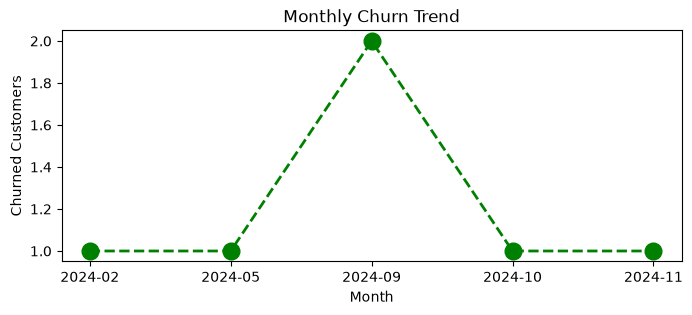

In [69]:
#1]monthly churn trend:this is time series kpi
df_visual['cancellation_month']=df_visual['cancellation_date'].dt.to_period('M')
churn_trend=df_visual[df_visual['churn_flag']==1].groupby('cancellation_month').size()
plt.figure(figsize=(8,3))
plt.plot(churn_trend.index.astype('str'),churn_trend.values,color='green', marker='o', linestyle='dashed',linewidth=2, markersize=12)

plt.title('Monthly Churn Trend')
plt.xlabel('Month')
plt.ylabel('Churned Customers')
plt.show()

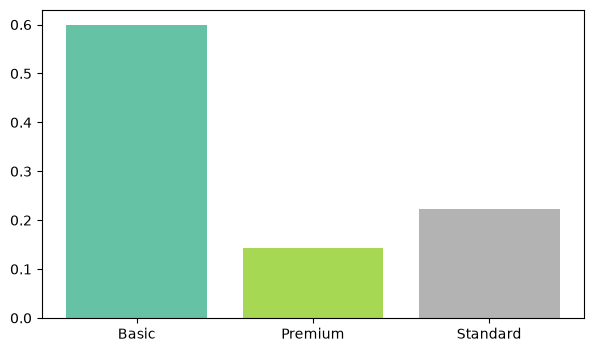

In [70]:
#2]churn by plan type
churn_plan=df_visual.groupby('plan_type')['churn_flag'].mean()
# colors=['pink','blue','purple']
colors=plt.cm.Set2(np.linspace(0,1,len(churn_plan)))
plt.figure(figsize=(7,4))
plt.bar(churn_plan.index,churn_plan.values,color=colors)
plt.show()

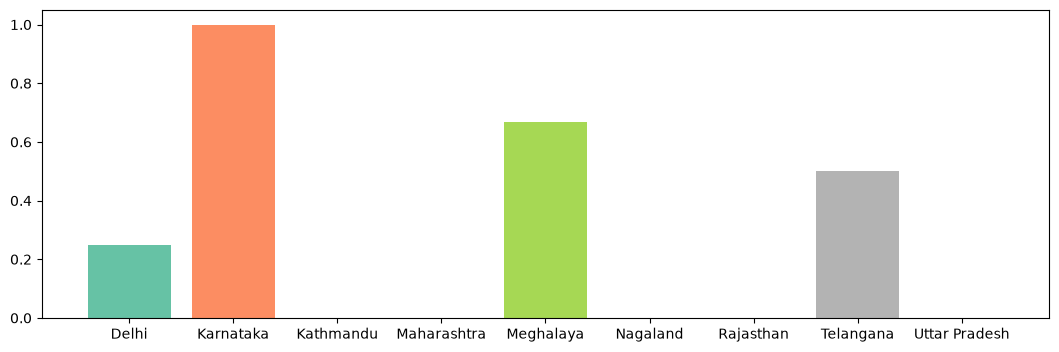

In [71]:
# 3]churn by states
churn_plan=df_visual.groupby('state')['churn_flag'].mean()

colors=plt.cm.Set2(np.linspace(0,1,len(churn_plan)))
plt.figure(figsize=(13,4))
plt.bar(churn_plan.index,churn_plan.values,color=colors)
plt.show()

In [72]:
#visualization using seaborn


In [73]:
#strinf to numeric-that is encoding
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk', 'cancellation_month'],
      dtype='object')

In [75]:
#incorrect method of encoding -as numbers are not assigned based on priority
# df_encoded=df_visual[['plan_type','contract_type','churn_score','churn_flag','churn_risk','escalations']].head()

# categorical_cols=['plan_type','contract_type','churn_risk']
# for col in categorical_cols:
#     df_encoded[col]=df_encoded[col].astype('category').cat.codes
    

In [76]:
df_visual['plan_type'].unique()

array(['Standard', 'Premium', 'Basic'], dtype=object)

In [77]:
df_visual['churn_risk'].unique()

array(['low', 'high', 'medium'], dtype=object)

In [78]:
df_visual['contract_type'].unique()

array(['Annual', 'Monthly'], dtype=object)

In [81]:
#correct method of encoding-based on priority
import pandas as pd

df_encoded = df_visual[
    ['plan_type', 'contract_type', 'churn_score',
     'churn_flag', 'churn_risk', 'escalations']
].head().copy()

order_mappings = {
    'plan_type': ['Basic', 'Standard', 'Premium'],
    'contract_type': ['Monthly', 'Annual'],
    'churn_risk': ['low', 'medium', 'high']
}

for col, order in order_mappings.items():
    df_encoded[col] = pd.Categorical(
        df_encoded[col],
        categories=order,
        ordered=True
    ).codes

print(df_encoded)

   plan_type  contract_type  churn_score  churn_flag  churn_risk  escalations
0          1              1           12           0           0            0
1          2              1           91           1           2            1
2          0              0           34           0           0            0
3          2              1            8           0           0            0
4          1              0           88           1           2            1


<Axes: >

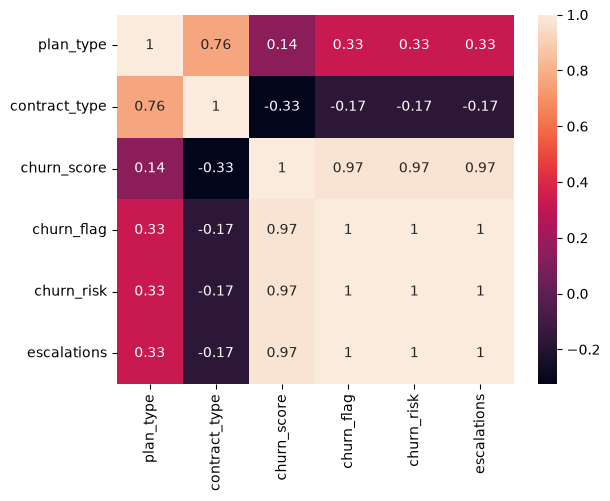

In [82]:
#1]heatmap(correlation matrix)

sns.heatmap(df_encoded.corr(),annot=True)

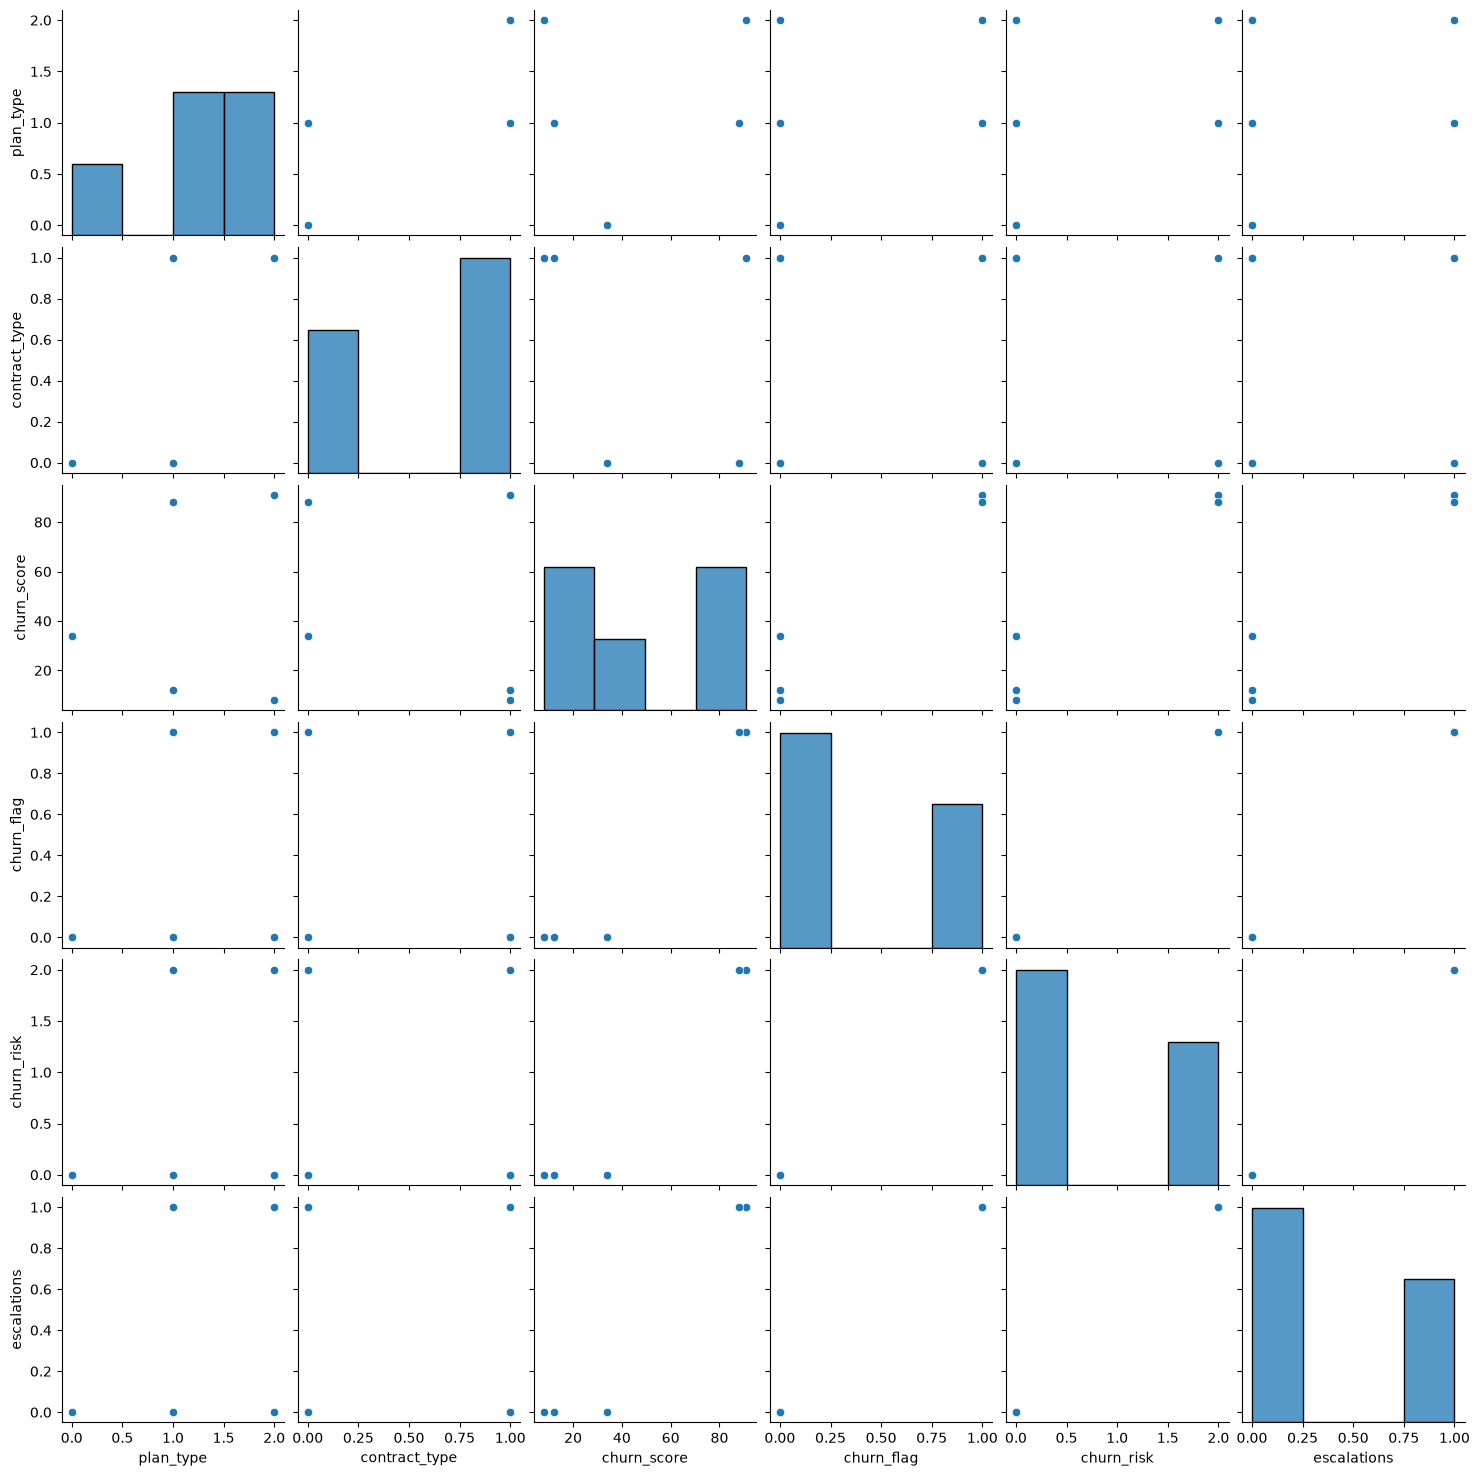

In [84]:
#pairplot:relationship in a dataset
sns.pairplot(df_encoded)

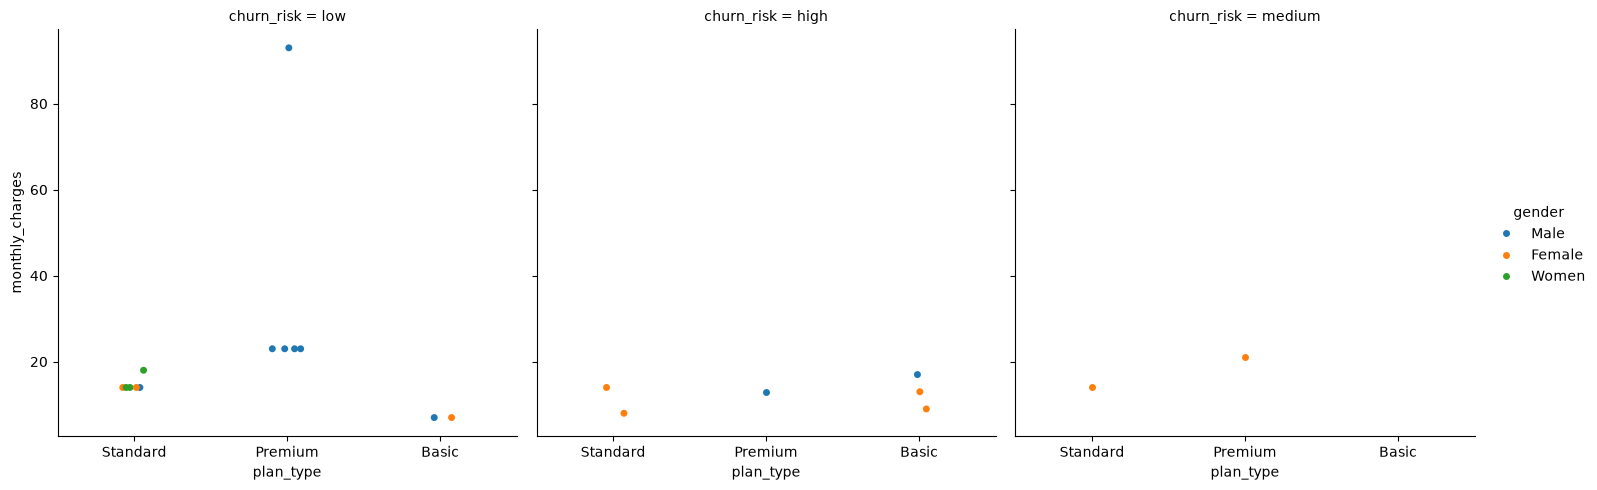

In [100]:
print(df_visual['gender'].unique())

['Male' 'Female' 'Women']


In [101]:
df_visual['gender'] = (
    df_visual['gender']
    .str.strip()
    .replace({'Women': 'Female'})
)

In [102]:
print(df_visual['gender'].value_counts())

gender
Female    12
Male       9
Name: count, dtype: int64


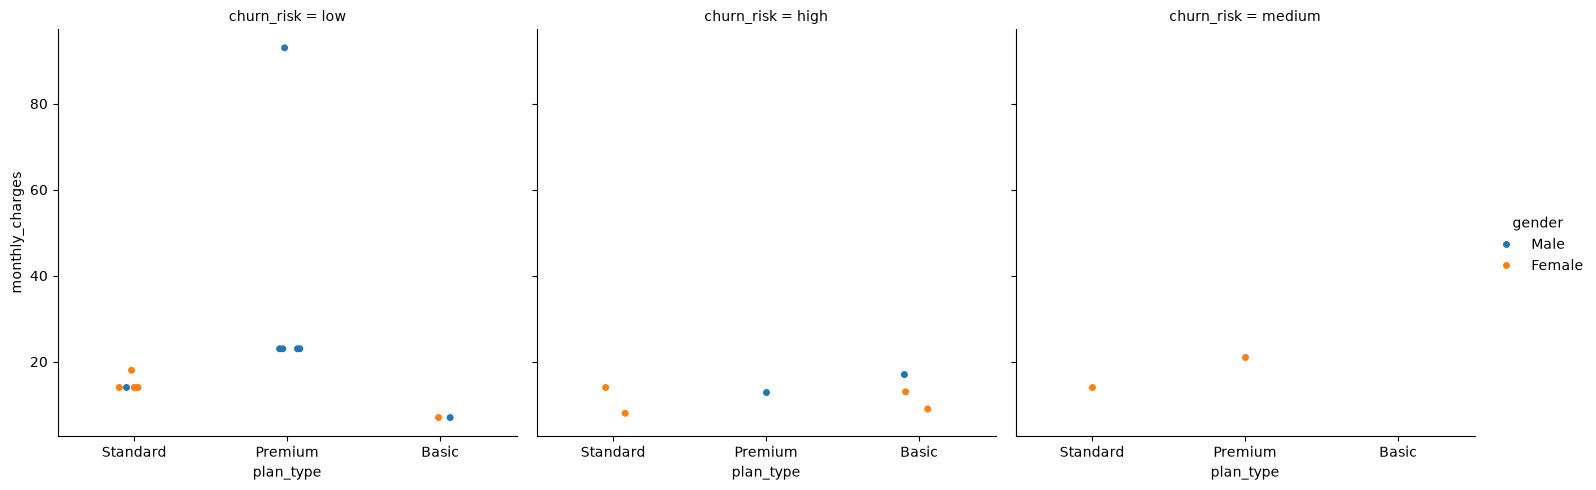

In [103]:
#catplot/facegrid plot:multi dimension comparison
sns.catplot(data=df_visual,
            x='plan_type',
            y='monthly_charges',
            hue='gender',
            col='churn_risk')

In [104]:
#pivot table

In [108]:
pd.pivot_table(
    df_visual,
    values='churn_flag',
    index='plan_type',
    aggfunc='mean'
).reset_index()

,plan_type,churn_flag
0,Basic,0.600000
1,Premium,0.142857
2,Standard,0.222222


In [111]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk', 'cancellation_month'],
      dtype='object')

In [112]:
pd.pivot_table(
    df_visual,
    index='plan_type',
    values=['monthly_charges','customerid','churn_flag'],
    aggfunc={
        'monthly_charges':'sum',
        'customerid':'nunique',
        'churn_flag':'mean'
    }
).reset_index()

,plan_type,churn_flag,customerid,monthly_charges
0,Basic,0.600000,5,52.95
1,Premium,0.142857,7,218.93
2,Standard,0.222222,9,123.91


In [ ]:
#working with sql in python(pandas)

In [113]:
#create database in sql
conn=sqlite3.connect('test_database.sqlite')
#table details
conn.execute("CREATE TABLE users(first_name TEXT,country TEXT,budget INTEGER)")
#commmit and save
conn.commit()

In [120]:
#insert data
cursor=conn.cursor()
cursor.execute(
    """
    INSERT INTO users VALUES 
    
        ('khush','INDIA','10000'),
        ('Rrista','INDIA','5000'),
        ('TtejjsiI','INdiA','60000')
    
    
    
    """
)
conn.commit()
print("data inserted succesfully")

data inserted succesfully


In [123]:
#check inserted data in table
conn=sqlite3.connect('test_database.sqlite')
query="""SELECT * FROM users"""
df_results=pd.read_sql(query,conn)
df_results.head()

,first_name,country,budget
0,khush,INDIA,10000
1,Rrista,INDIA,5000
2,TtejjsiI,INdiA,60000
3,khush,INDIA,10000
4,Rrista,INDIA,5000


In [124]:
#aggregation
query="""
SELECT country,sum(budget) as total_budget
FROM users
GROUP BY country

"""
df_agg=pd.read_sql(query,conn)
df_agg.head()

,country,total_budget
0,INDIA,30000
1,INdiA,120000


In [125]:
#always close the conn with database once the task is done
conn.close()